In [19]:
# Loading relevant libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
# Loading the dataset.
studygroup = pd.read_csv('sg_studentdata.csv')

# Display basic information
print(studygroup.info())
print(studygroup.describe())

# Check for missing values
print(studygroup.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71754 entries, 0 to 71753
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Centre             71754 non-null  object 
 1   Programme          71754 non-null  object 
 2   Area               71754 non-null  object 
 3   Region             71754 non-null  object 
 4   Sub Region         70946 non-null  object 
 5   Country            71754 non-null  object 
 6   Branch URN         71754 non-null  object 
 7   Group URN          71754 non-null  object 
 8   Lead Source        71754 non-null  object 
 9   Student ID         71754 non-null  int64  
 10  Booking ID         71754 non-null  int64  
 11  Nationality        71754 non-null  object 
 12  IntakeYear         71754 non-null  int64  
 13  IntakeQuarter      71754 non-null  int64  
 14  Application Date   71754 non-null  object 
 15  Offered Date       51892 non-null  object 
 16  Confirmation Date  643

In [4]:
sg_dummies = studygroup.drop(columns=['Area', ])

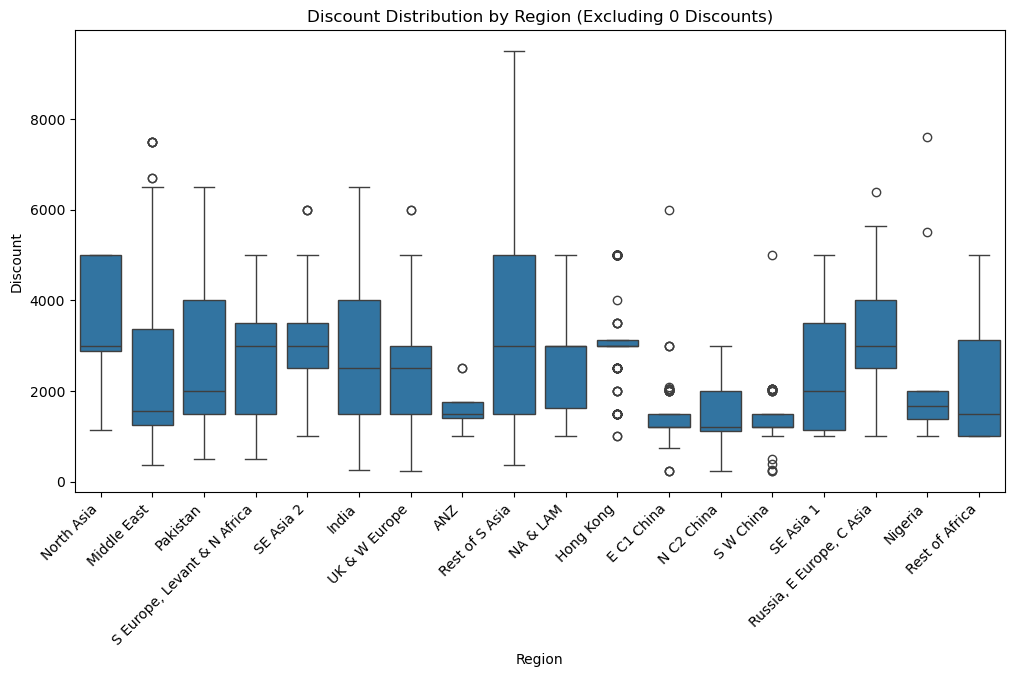

In [5]:
# Filter out rows where 'Discount Type' is missing (NaN)
filtered_studygroup = studygroup.dropna(subset=['Discount Type'])

# Discount distribution by region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Discount', data=filtered_studygroup)
plt.title('Discount Distribution by Region (Excluding 0 Discounts)')
plt.xticks(rotation=45, ha='right')
plt.show()

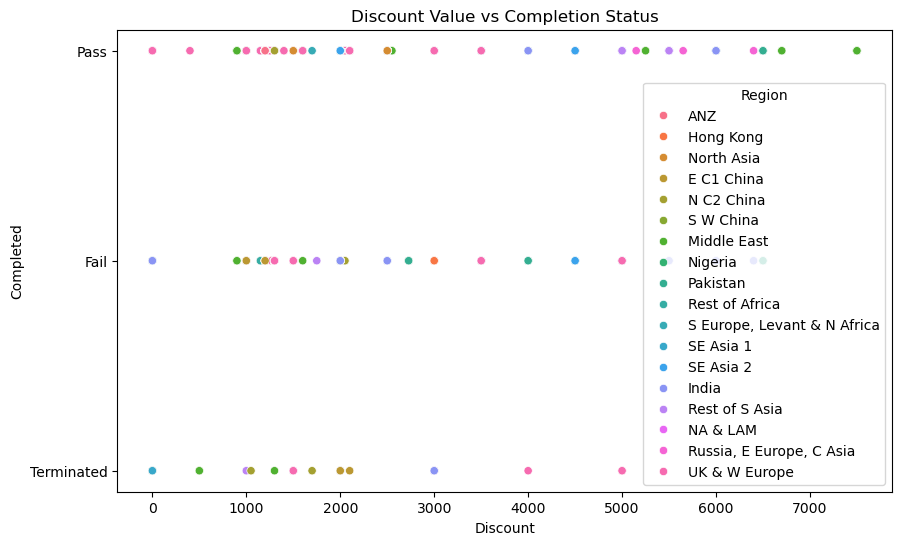

In [7]:
# Scatter plot of discount value vs completion status
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Completed', hue='Region', data=studygroup)
plt.title('Discount Value vs Completion Status')
plt.show()

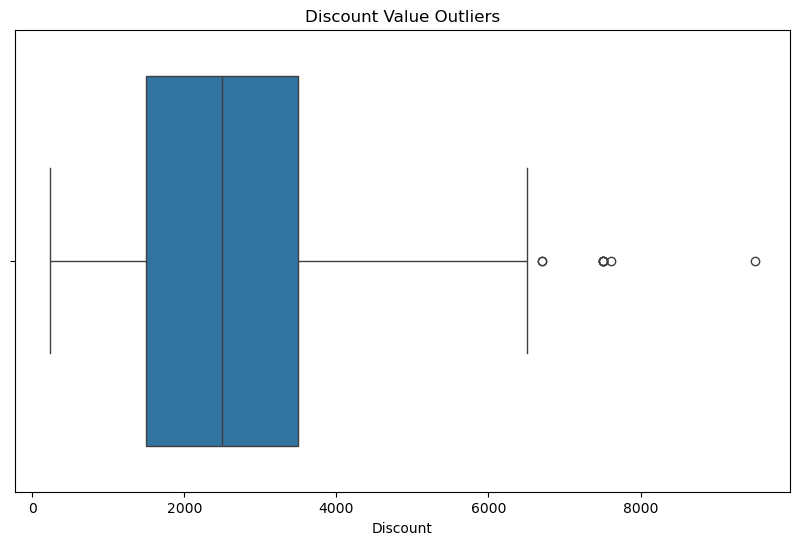

In [9]:
# Identify outliers in discount values
plt.figure(figsize=(10, 6))
sns.boxplot(x='Discount', data=filtered_studygroup)
plt.title('Discount Value Outliers')
plt.show()

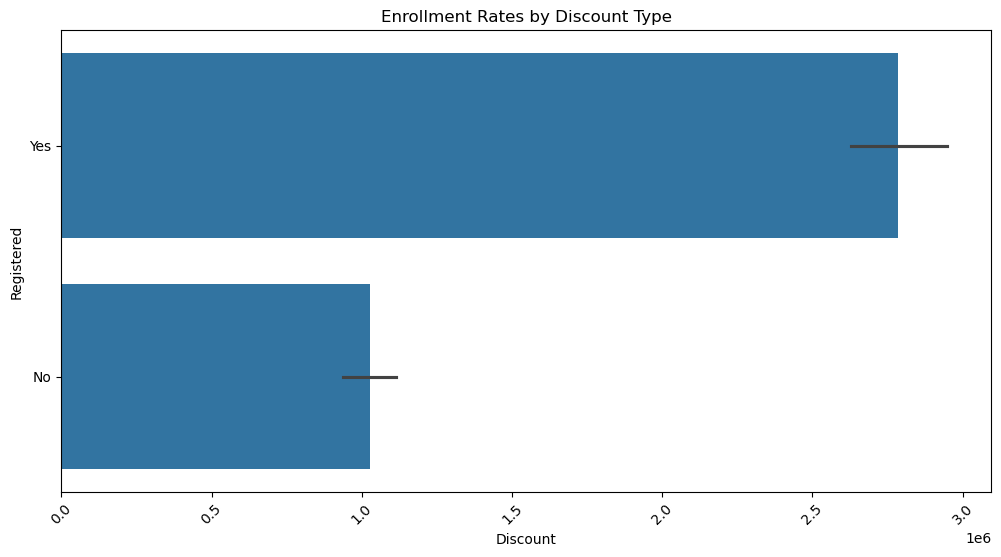

In [12]:
# Bar plot of enrollment rates by discount type
plt.figure(figsize=(12, 6))
sns.barplot(x='Discount', y='Registered', data=studygroup, estimator=sum)
plt.title('Enrollment Rates by Discount Type')
plt.xticks(rotation=45)
plt.show()

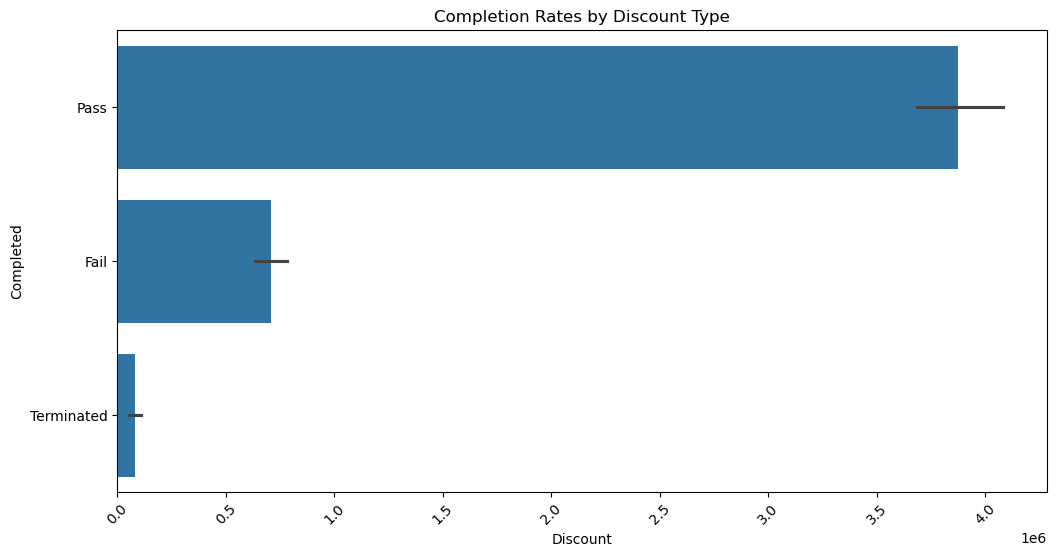

In [7]:
# Bar plot of completion rates by discount type
plt.figure(figsize=(12, 6))
sns.barplot(x='Discount', y='Completed', data=studygroup, estimator=sum)
plt.title('Completion Rates by Discount Type')
plt.xticks(rotation=45)
plt.show()

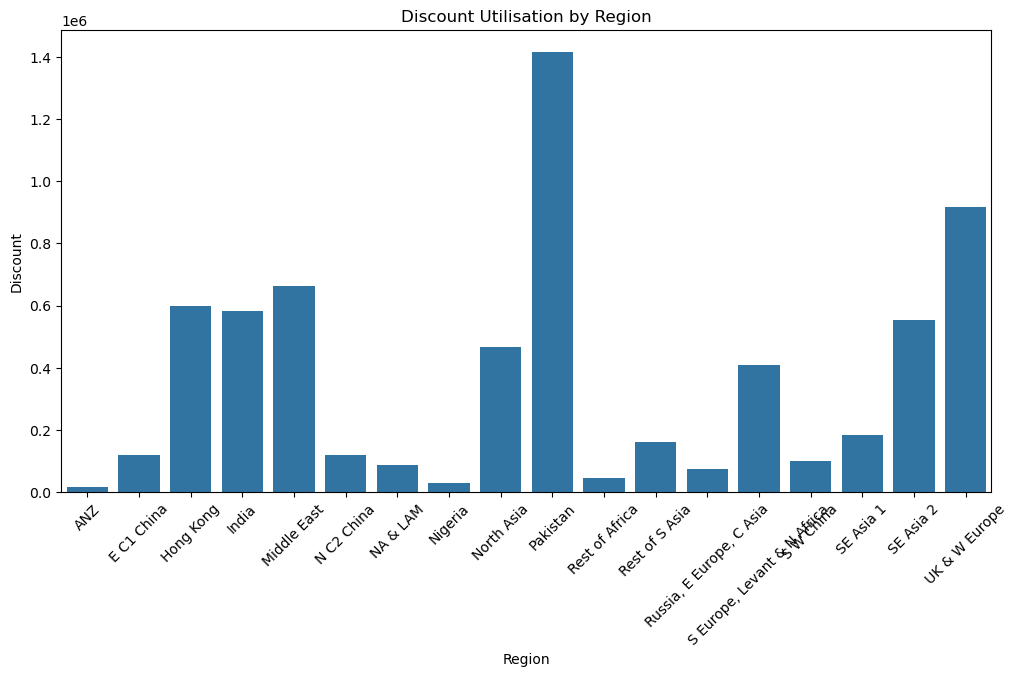

In [14]:
# Discount utilization by region
discount_utilization = studygroup.groupby('Region')['Discount'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='Discount', data=discount_utilization)
plt.title('Discount Utilisation by Region')
plt.xticks(rotation=45)
plt.show()

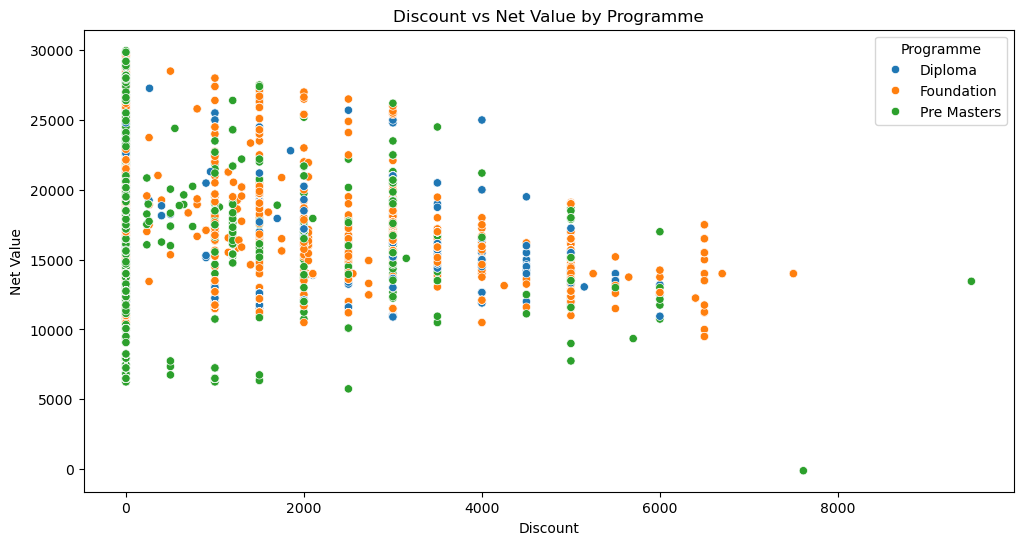

In [9]:
# Scatter plot of discount vs net value by program
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Discount', y='Net Value', hue='Programme', data=studygroup)
plt.title('Discount vs Net Value by Programme')
plt.show()

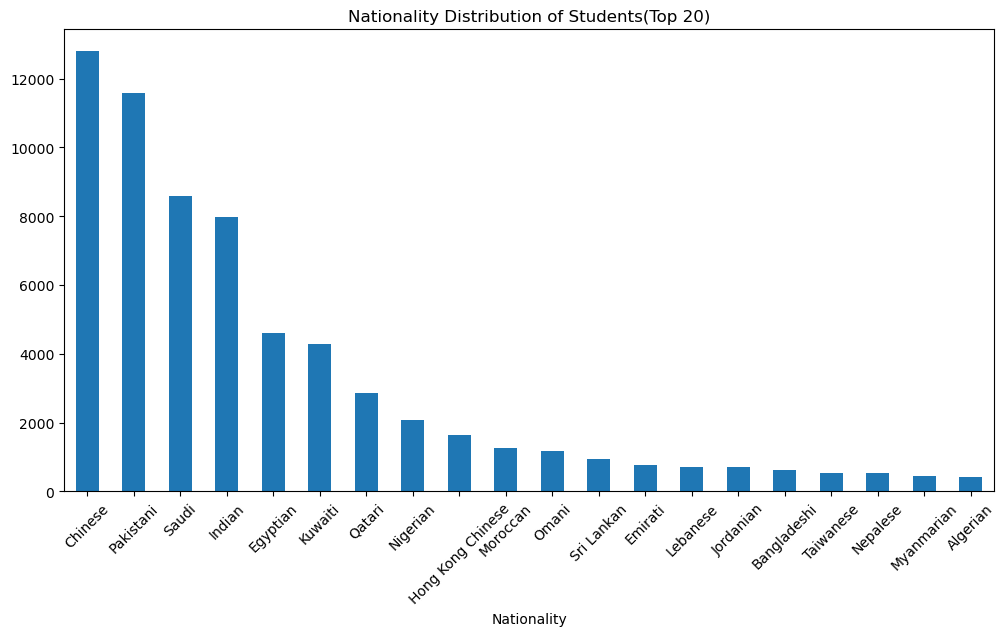

In [10]:
# Nationality distribution of students
plt.figure(figsize=(12, 6))
studygroup['Nationality'].value_counts().head(20).plot(kind='bar')
plt.title('Nationality Distribution of Students(Top 20)')
plt.xticks(rotation=45)
plt.show()

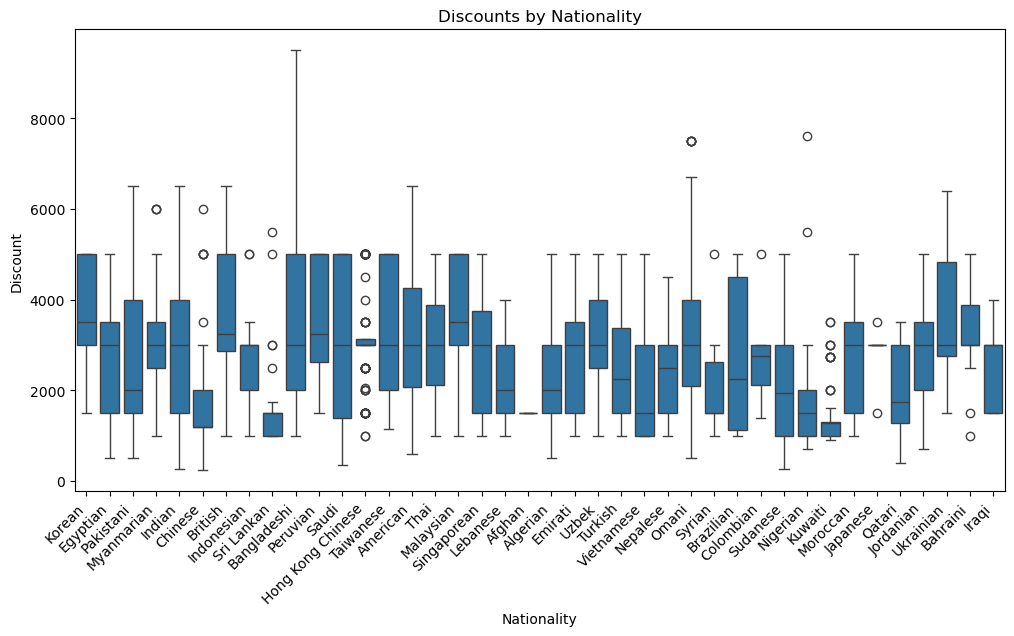

In [17]:
# Discounts by nationality
top_nationalities = filtered_studygroup['Nationality'].value_counts().head(40).index
filtered_df = filtered_studygroup[filtered_studygroup['Nationality'].isin(top_nationalities)]
plt.figure(figsize=(12, 6))
sns.boxplot(x='Nationality', y='Discount', data=filtered_df)
plt.title('Discounts by Nationality')
plt.xticks(rotation=45, ha='right')
plt.show()

After visualizing the data, summarize the findings:

Are discounts being misused (e.g., unusually high discounts in certain regions or programs)?

Are there regions or programs where discounts are underutilized?

Are discounts effectively driving enrollment, completion, and progression rates?

Are students from outside the UK being targeted effectively?

Based on the analysis, provide actionable recommendations:

Adjust discount strategies for underperforming regions or programs.

Investigate outliers in discount usage.

Increase discounts in regions or programs with high potential for growth.

Focus marketing efforts on nationalities with low enrollment but high potential.



In [29]:
import re

def clean_entry(text):
    if not isinstance(text, str):
        text = ''
    # Remove numbers (including those with commas or decimals)
    cleaned = re.sub(r'\d+(?:[,\.\d]*)', '', text)
    # Remove currency codes and symbols (case-insensitive)
    cleaned = re.sub(r'(?i)\b(?:GBP|£)\b', '', cleaned)
    # Remove hyphens and slashes used as separators
    cleaned = re.sub(r'[-/]', ' ', cleaned)
    # Remove any leftover extra whitespace
    cleaned = ' '.join(cleaned.split())
    return cleaned

studygroup['Discount Type Clean'] = [clean_entry(entry) for entry in studygroup['Discount Type']]

In [32]:
print(studygroup['Discount Type Clean'].value_counts().sort_index())
print(len(studygroup['Discount Type'].unique()))
print(len(studygroup['Discount Type Clean'].unique()))

Discount Type Clean
                                                                                              69270
Bursary                                                                                           2
Bursary ( )                                                                                       3
Bursary approval                                                                                  2
Center Excellence                                                                                 1
Center Of Excellence                                                                             41
Center of Excellence                                                                           1686
Center of Excellence £                                                                            2
Center of Execellence                                                                             2
Center of excellence                                                            